In [15]:
!pip install fastf1 scipy matplotlib pandas numpy --quiet

In [16]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import warnings
import os
warnings.filterwarnings('ignore')

# Cache local para não rebaixar os dados toda vez
os.makedirs('f1_cache', exist_ok=True)
fastf1.Cache.enable_cache('f1_cache')

print('FastF1 versão:', fastf1.__version__)

FastF1 versão: 3.8.3


In [17]:
session = fastf1.get_session(2022, 'Saudi Arabia', 'R')
session.load(laps=True, telemetry=True, weather=True, messages=True)
laps = session.laps

# Tempo de serviço = LapTime da volta de pit MENOS tempo médio de volta normal
lap_times_normal = []
for driver in laps['Driver'].unique():
    drv = laps[laps['Driver'] == driver].sort_values('LapNumber')
    normal = drv[drv['IsAccurate'] == True]['LapTime'].dt.total_seconds()
    if len(normal) > 0:
        lap_times_normal.append(normal.median())

avg_lap = np.median(lap_times_normal)
print(f'Tempo médio de volta normal: {avg_lap:.2f} s')

pit_rows = []
for driver in laps['Driver'].unique():
    drv = laps[laps['Driver'] == driver].sort_values('LapNumber').reset_index(drop=True)
    for i in range(1, len(drv)):
        curr = drv.iloc[i]
        prev = drv.iloc[i-1]
        if pd.notna(curr['TyreLife']) and pd.notna(prev['TyreLife']):
            if curr['TyreLife'] <= 2 and prev['TyreLife'] > 3:
                lap_time_s = curr['LapTime'].total_seconds() if pd.notna(curr['LapTime']) else None
                if lap_time_s:
                    pit_duration = lap_time_s - avg_lap  # subtrai volta normal
                    if 15 <= pit_duration <= 60:  # filtra duracoes realistas
                        pit_rows.append({
                            'Driver': driver,
                            'LapNumber': curr['LapNumber'],
                            'pit_duration_s': pit_duration,
                            'pit_in_s': curr['LapStartTime'].total_seconds() if pd.notna(curr['LapStartTime']) else None
                        })

pit_laps = pd.DataFrame(pit_rows).dropna()
print(f'Pit stops válidos: {len(pit_laps)}')
print(f'Duração média: {pit_laps["pit_duration_s"].mean():.2f} s')
print(pit_laps.head(10))

core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Saudi Arabian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
c

Tempo médio de volta normal: 95.68 s
Pit stops válidos: 10
Duração média: 34.87 s
  Driver  LapNumber  pit_duration_s  pit_in_s
0    GAS       16.0        48.04925  5214.393
1    PER       16.0        32.42425  5173.958
2    STR       14.0        20.61525  5030.761
3    ALB       14.0        19.73125  5035.669
4    HUL       38.0        48.63625  7577.792
5    RIC        9.0        18.46625  4538.724
6    OCO       17.0        50.29525  5332.349
7    NOR       17.0        52.90425  5336.262
8    HAM       41.0        17.38025  7920.645
9    BOT       36.0        40.14925  7370.052


# Coleta dados

In [18]:
session = fastf1.get_session(2022, 'Saudi Arabia', 'R')
session.load(laps=True, telemetry=True, weather=True, messages=True)
laps = session.laps
print(f'Corrida: {session.event["EventName"]} {session.event.year}')
print(f'Pilotos: {laps["Driver"].nunique()}')

core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Saudi Arabian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
c

Corrida: Saudi Arabian Grand Prix 2022
Pilotos: 18


In [19]:
# Tempo médio de volta normal (referência)
lap_times_normal = []
for driver in laps['Driver'].unique():
    drv = laps[laps['Driver'] == driver].sort_values('LapNumber')
    normal = drv[drv['IsAccurate'] == True]['LapTime'].dt.total_seconds()
    if len(normal) > 0:
        lap_times_normal.append(normal.median())
avg_lap = np.median(lap_times_normal)
print(f'Tempo médio de volta normal: {avg_lap:.2f} s')

# Detecta pit stops pela mudança de pneu (TyreLife volta a 1)
pit_rows = []
for driver in laps['Driver'].unique():
    drv = laps[laps['Driver'] == driver].sort_values('LapNumber').reset_index(drop=True)
    for i in range(1, len(drv)):
        curr = drv.iloc[i]
        prev = drv.iloc[i-1]
        if pd.notna(curr['TyreLife']) and pd.notna(prev['TyreLife']):
            if curr['TyreLife'] <= 2 and prev['TyreLife'] > 3:
                lap_time_s = curr['LapTime'].total_seconds() if pd.notna(curr['LapTime']) else None
                if lap_time_s:
                    pit_duration = lap_time_s - avg_lap
                    if 15 <= pit_duration <= 60:
                        pit_rows.append({
                            'Driver': driver,
                            'LapNumber': curr['LapNumber'],
                            'pit_duration_s': pit_duration,
                            'pit_in_s': curr['LapStartTime'].total_seconds() if pd.notna(curr['LapStartTime']) else None
                        })

pit_laps = pd.DataFrame(pit_rows).dropna().reset_index(drop=True)
print(f'Pit stops válidos: {len(pit_laps)}')
print(f'Duração média: {pit_laps["pit_duration_s"].mean():.2f} s')
print(pit_laps.head(10))

Tempo médio de volta normal: 95.68 s
Pit stops válidos: 10
Duração média: 34.87 s
  Driver  LapNumber  pit_duration_s  pit_in_s
0    GAS       16.0        48.04925  5214.393
1    PER       16.0        32.42425  5173.958
2    STR       14.0        20.61525  5030.761
3    ALB       14.0        19.73125  5035.669
4    HUL       38.0        48.63625  7577.792
5    RIC        9.0        18.46625  4538.724
6    OCO       17.0        50.29525  5332.349
7    NOR       17.0        52.90425  5336.262
8    HAM       41.0        17.38025  7920.645
9    BOT       36.0        40.14925  7370.052


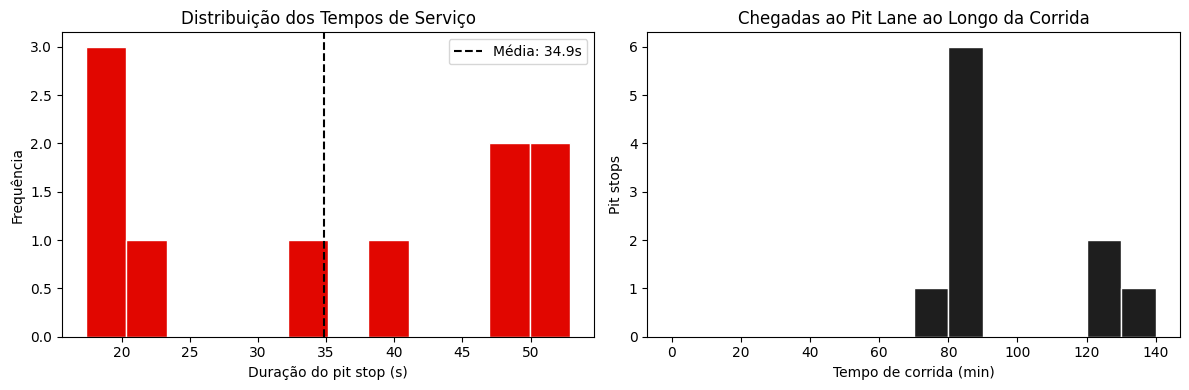

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pit_laps['pit_duration_s'], bins=12, color='#e10600', edgecolor='white')
axes[0].axvline(pit_laps['pit_duration_s'].mean(), color='black', linestyle='--',
                label=f'Média: {pit_laps["pit_duration_s"].mean():.1f}s')
axes[0].set_xlabel('Duração do pit stop (s)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição dos Tempos de Serviço')
axes[0].legend()

pit_laps['pit_in_min'] = pit_laps['pit_in_s'] / 60
bins_time = np.arange(0, pit_laps['pit_in_min'].max() + 10, 10)
axes[1].hist(pit_laps['pit_in_min'], bins=bins_time, color='#1e1e1e', edgecolor='white')
axes[1].set_xlabel('Tempo de corrida (min)')
axes[1].set_ylabel('Pit stops')
axes[1].set_title('Chegadas ao Pit Lane ao Longo da Corrida')

plt.tight_layout()
plt.savefig('pit_stops_exploratorio.png', dpi=150, bbox_inches='tight')
plt.show()

# Analise Exploratoria

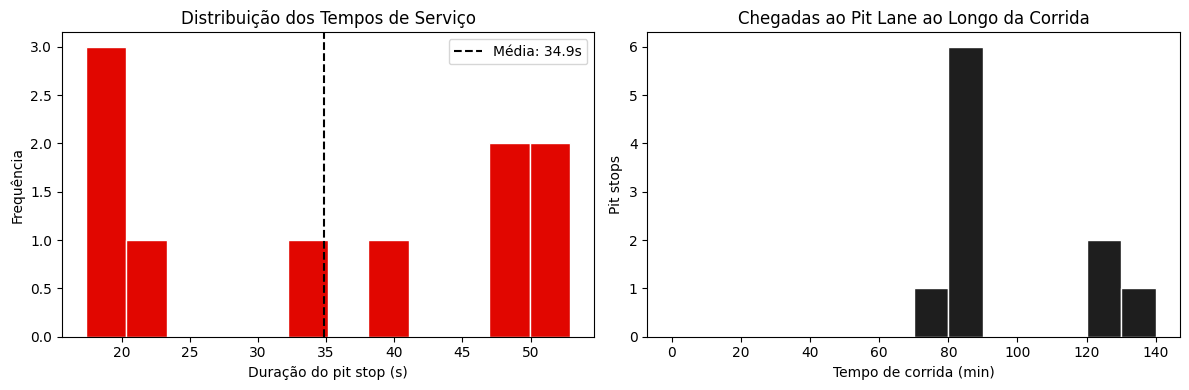

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pit_laps['pit_duration_s'], bins=12, color='#e10600', edgecolor='white')
axes[0].axvline(pit_laps['pit_duration_s'].mean(), color='black', linestyle='--',
                label=f'Média: {pit_laps["pit_duration_s"].mean():.1f}s')
axes[0].set_xlabel('Duração do pit stop (s)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição dos Tempos de Serviço')
axes[0].legend()

pit_laps['pit_in_min'] = pit_laps['pit_in_s'] / 60
bins_time = np.arange(0, pit_laps['pit_in_min'].max() + 10, 10)
axes[1].hist(pit_laps['pit_in_min'], bins=bins_time, color='#1e1e1e', edgecolor='white')
axes[1].set_xlabel('Tempo de corrida (min)')
axes[1].set_ylabel('Pit stops')
axes[1].set_title('Chegadas ao Pit Lane ao Longo da Corrida')

plt.tight_layout()
plt.savefig('pit_stops_exploratorio.png', dpi=150, bbox_inches='tight')
plt.show()

# Parâmetros


- **λ** = taxa de chegada (pit stops/hora)
- **μ** = taxa de serviço por canal (atend./hora)
- **S** = número de canais (boxes ativos)
- **ρ = λ/μ** (intensidade de tráfego)
- **Condição de estabilidade**: λ < μ·S  →  ρ < S

In [22]:
T_race_s = pit_laps['pit_in_s'].max() + pit_laps['pit_duration_s'].iloc[-1]
T_race_h = T_race_s / 3600

lam = len(pit_laps) / T_race_h          # λ: pit stops/hora
mean_service_s = pit_laps['pit_duration_s'].mean()
mu = 3600 / mean_service_s               # μ: atendimentos/hora por canal
S = laps['Driver'].nunique()             # S: canais (equipes)
rho = lam / mu                           # ρ = λ/μ

print('=' * 50)
print('  Parâmetros do Modelo M/M/S — Bahrein 2023')
print('=' * 50)
print(f'  Duração da corrida        : {T_race_h*60:.1f} min')
print(f'  Total de pit stops        : {len(pit_laps)}')
print(f'  Canais de serviço (S)     : {S}')
print(f'  λ (chegadas/hora)         : {lam:.4f}')
print(f'  μ (atend./hora/canal)     : {mu:.4f}')
print(f'  Tempo médio de serviço    : {mean_service_s:.2f} s')
print(f'  ρ = λ/μ                   : {rho:.4f}')
print(f'  Condição λ < μ·S          : {lam:.2f} < {mu*S:.2f} → {"OK ✓" if lam < mu*S else "VIOLADA ✗"}')
print('=' * 50)

  Parâmetros do Modelo M/M/S — Bahrein 2023
  Duração da corrida        : 132.7 min
  Total de pit stops        : 10
  Canais de serviço (S)     : 18
  λ (chegadas/hora)         : 4.5222
  μ (atend./hora/canal)     : 103.2550
  Tempo médio de serviço    : 34.87 s
  ρ = λ/μ                   : 0.0438
  Condição λ < μ·S          : 4.52 < 1858.59 → OK ✓


# Modelo M/M/S

**P₀** (probabilidade de 0 clientes no sistema):
$$P_0 = \frac{1}{\sum_{j=0}^{S-1} \frac{\rho^j}{j!} + \frac{\rho^S}{(S-1)!(S-\rho)}}$$


**P_ocup.total** (todos os canais ocupados):
$$P_{ocup.total} = \frac{\rho^S}{(S-1)!(S-\rho)} \cdot P_0$$


**Medidas de efetividade:**
$$NF = \frac{\rho}{S-\rho} \cdot P_{ocup.total} \qquad TF = NF \cdot \frac{1}{\lambda}$$
$$NS = NF + \rho \qquad TS = NS \cdot \frac{1}{\lambda}$$

In [23]:
def mms(lam, mu, S):
    rho = lam / mu
    if rho >= S:
        print('Sistema instável: ρ >= S'); return None
    soma = sum(rho**j / factorial(j) for j in range(S))
    ultimo = rho**S / (factorial(S-1) * (S - rho))
    P0 = 1.0 / (soma + ultimo)
    P_ocup = (rho**S / (factorial(S-1) * (S - rho))) * P0
    NF = (rho / (S - rho)) * P_ocup
    TF = NF / lam
    NS = NF + rho
    TS = NS / lam
    return {'S':S, 'rho':rho, 'P0':P0, 'P_ocup':P_ocup,
            'NF':NF, 'TF_s':TF*3600, 'NS':NS, 'TS_s':TS*3600}

r = mms(lam, mu, S)
if r:
    print('=' * 50)
    print(f'  Resultados M/M/{S} — GP Bahrein 2023')
    print('=' * 50)
    print(f'  ρ = λ/μ                    : {r["rho"]:.4f}')
    print(f'  P₀ (prob. sistema vazio)   : {r["P0"]:.6f}')
    print(f'  P_ocup.total               : {r["P_ocup"]:.6f}')
    print(f'  NF (clientes na fila)      : {r["NF"]:.4f}')
    print(f'  TF (tempo médio na fila)   : {r["TF_s"]:.4f} s')
    print(f'  NS (clientes no sistema)   : {r["NS"]:.4f}')
    print(f'  TS (tempo médio no sist.)  : {r["TS_s"]:.2f} s')
    print('=' * 50)

  Resultados M/M/18 — GP Bahrein 2023
  ρ = λ/μ                    : 0.0438
  P₀ (prob. sistema vazio)   : 0.957149
  P_ocup.total               : 0.000000
  NF (clientes na fila)      : 0.0000
  TF (tempo médio na fila)   : 0.0000 s
  NS (clientes no sistema)   : 0.0438
  TS (tempo médio no sist.)  : 34.87 s


# Variação do S em análise de sesibilidade

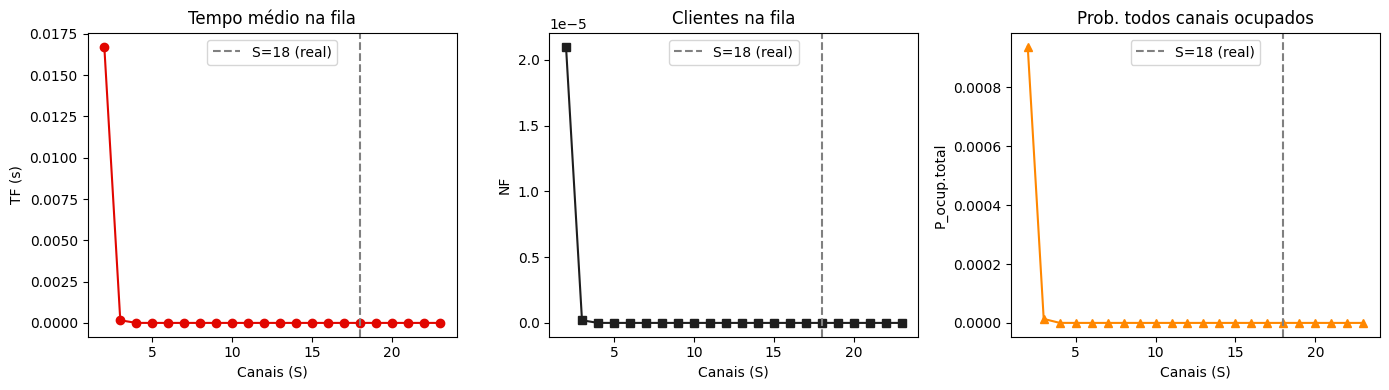

 S    rho  P_ocup     NF   TF_s     NS    TS_s
 2 0.0438  0.0009 0.0000 0.0167 0.0438 34.8819
 3 0.0438  0.0000 0.0000 0.0002 0.0438 34.8653
 4 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
 5 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
 6 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
 7 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
 8 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
 9 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
10 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
11 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
12 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
13 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
14 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
15 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
16 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
17 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
18 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
19 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
20 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
21 0.0438  0.0000 0.0000 0.0000 0.0438 34.8652
22 0.0438  0.

In [24]:
import math
S_min = math.ceil(lam / mu) + 1
rows = [mms(lam, mu, s) for s in range(S_min, S + 6) if mms(lam, mu, s)]
df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(df['S'], df['TF_s'], 'o-', color='#e10600')
axes[0].axvline(S, linestyle='--', color='gray', label=f'S={S} (real)')
axes[0].set_xlabel('Canais (S)'); axes[0].set_ylabel('TF (s)')
axes[0].set_title('Tempo médio na fila'); axes[0].legend()

axes[1].plot(df['S'], df['NF'], 's-', color='#1e1e1e')
axes[1].axvline(S, linestyle='--', color='gray', label=f'S={S} (real)')
axes[1].set_xlabel('Canais (S)'); axes[1].set_ylabel('NF')
axes[1].set_title('Clientes na fila'); axes[1].legend()

axes[2].plot(df['S'], df['P_ocup'], '^-', color='#ff8700')
axes[2].axvline(S, linestyle='--', color='gray', label=f'S={S} (real)')
axes[2].set_xlabel('Canais (S)'); axes[2].set_ylabel('P_ocup.total')
axes[2].set_title('Prob. todos canais ocupados'); axes[2].legend()

plt.tight_layout()
plt.savefig('sensibilidade_canais.png', dpi=150, bbox_inches='tight')
plt.show()

print(df[['S','rho','P_ocup','NF','TF_s','NS','TS_s']].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Resumo Bahrain 2023

In [25]:
print('=' * 55)
print('  RESUMO — Teoria de Filas M/M/S')
print('  GP do Bahrein 2023 — Pit Lane F1')
print('=' * 55)
print(f'  Modelo                     : M/M/{S}')
print(f'  λ (chegadas/hora)          : {lam:.4f}')
print(f'  μ (atend./hora/canal)      : {mu:.4f}')
print(f'  Tempo médio de serviço     : {mean_service_s:.2f} s')
print(f'  S (canais)                 : {S}')
print(f'  ρ = λ/μ                    : {r["rho"]:.4f}')
print(f'  P₀                         : {r["P0"]:.6f}')
print(f'  P_ocup.total               : {r["P_ocup"]:.6f}')
print(f'  NF (clientes na fila)      : {r["NF"]:.4f}')
print(f'  TF (tempo na fila)         : {r["TF_s"]:.4f} s')
print(f'  NS (clientes no sistema)   : {r["NS"]:.4f}')
print(f'  TS (tempo no sistema)      : {r["TS_s"]:.2f} s')
print('=' * 55)

  RESUMO — Teoria de Filas M/M/S
  GP do Bahrein 2023 — Pit Lane F1
  Modelo                     : M/M/18
  λ (chegadas/hora)          : 4.5222
  μ (atend./hora/canal)      : 103.2550
  Tempo médio de serviço     : 34.87 s
  S (canais)                 : 18
  ρ = λ/μ                    : 0.0438
  P₀                         : 0.957149
  P_ocup.total               : 0.000000
  NF (clientes na fila)      : 0.0000
  TF (tempo na fila)         : 0.0000 s
  NS (clientes no sistema)   : 0.0438
  TS (tempo no sistema)      : 34.87 s


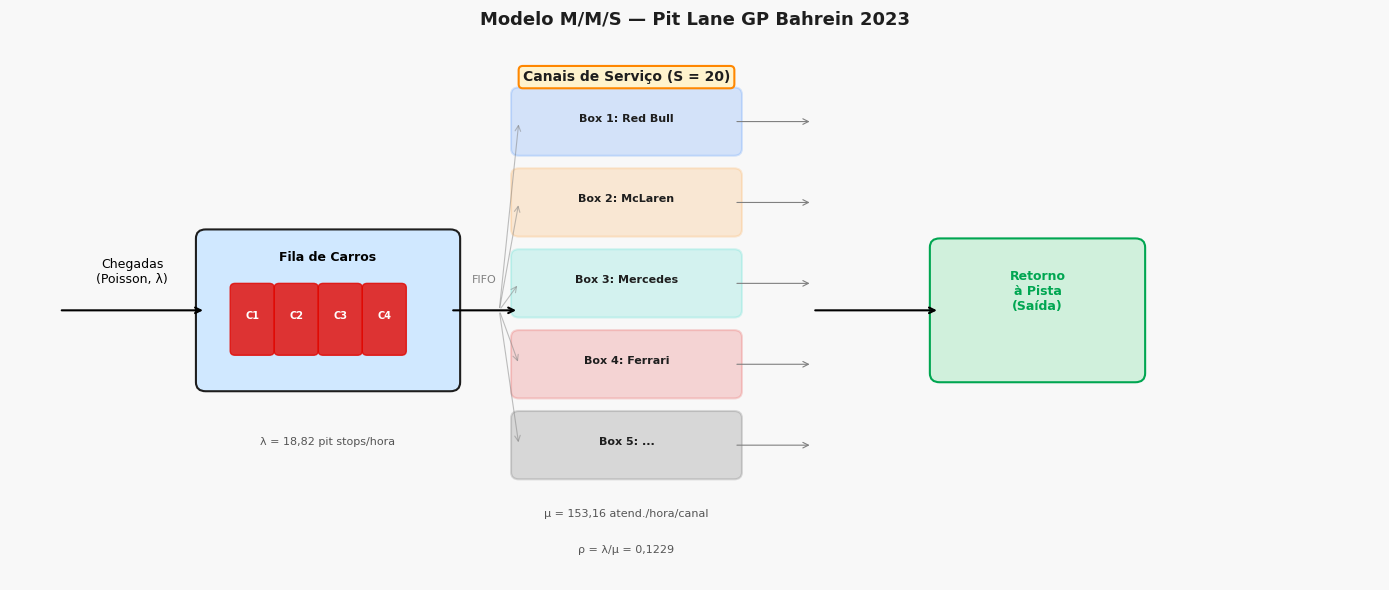

Figura salva: diagrama_sistema_filas.png


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_facecolor('#f8f8f8')
fig.patch.set_facecolor('#f8f8f8')

# ── Chegadas ──────────────────────────────────────────────────────────────
ax.annotate('', xy=(2.0, 3.0), xytext=(0.5, 3.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(1.25, 3.3, 'Chegadas\n(Poisson, λ)', ha='center', fontsize=9)

# ── Fila ──────────────────────────────────────────────────────────────────
fila = FancyBboxPatch((2.0, 2.2), 2.5, 1.6,
                      boxstyle="round,pad=0.1",
                      linewidth=1.5, edgecolor='#1e1e1e', facecolor='#d0e8ff')
ax.add_patch(fila)
ax.text(3.25, 3.55, 'Fila de Carros', ha='center', fontsize=9, fontweight='bold')

# carrinhos na fila
for i, x in enumerate([2.3, 2.75, 3.2, 3.65]):
    carro = FancyBboxPatch((x, 2.55), 0.35, 0.7,
                           boxstyle="round,pad=0.05",
                           linewidth=1, edgecolor='#e10600', facecolor='#e10600', alpha=0.8)
    ax.add_patch(carro)
    ax.text(x + 0.175, 2.9, f'C{i+1}', ha='center', fontsize=7, color='white', fontweight='bold')

# ── Seta fila → boxes ─────────────────────────────────────────────────────
ax.annotate('', xy=(5.2, 3.0), xytext=(4.5, 3.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(4.85, 3.3, 'FIFO', ha='center', fontsize=8, color='gray')

# ── Boxes (canais S) ──────────────────────────────────────────────────────
box_colors = ['#0067ff', '#ff8700', '#00d2be', '#e10600', '#1e1e1e']
box_labels = ['Red Bull', 'McLaren', 'Mercedes', 'Ferrari', '...']
y_positions = [4.8, 3.9, 3.0, 2.1, 1.2]


#box_colors = ['#e10600', '#ff8700', '#00d2be', '#1e1e1e', '#0067ff']
#box_labels = ['Red Bull', 'McLaren', 'Mercedes', 'Ferrari', '...']
#y_positions = [4.8, 3.9, 3.0, 2.1, 1.2]





for i, (ypos, cor, label) in enumerate(zip(y_positions, box_colors, box_labels)):
    # linha da fila para o box
    ax.annotate('', xy=(5.2, ypos + 0.3), xytext=(5.0, 3.0),
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8, alpha=0.5))
    # box
    box = FancyBboxPatch((5.2, ypos), 2.2, 0.6,
                         boxstyle="round,pad=0.08",
                         linewidth=1.5, edgecolor=cor, facecolor=cor, alpha=0.15)
    ax.add_patch(box)
    ax.text(6.3, ypos + 0.3, f'Box {i+1}: {label}', ha='center', fontsize=8,
            color='#1e1e1e', fontweight='bold')
    # seta saída
    ax.annotate('', xy=(8.2, ypos + 0.3), xytext=(7.4, ypos + 0.3),
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# ── Rótulo canais ─────────────────────────────────────────────────────────
ax.text(6.3, 5.55, f'Canais de Serviço (S = 20)', ha='center',
        fontsize=10, fontweight='bold', color='#1e1e1e',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3cd', edgecolor='#ff8700', lw=1.5))

# ── Saída ─────────────────────────────────────────────────────────────────
ax.annotate('', xy=(9.5, 3.0), xytext=(8.2, 3.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
saida = FancyBboxPatch((9.5, 2.3), 2.0, 1.4,
                       boxstyle="round,pad=0.1",
                       linewidth=1.5, edgecolor='#00a651', facecolor='#d0f0dc')
ax.add_patch(saida)
ax.text(10.5, 3.0, 'Retorno\nà Pista\n(Saída)', ha='center', fontsize=9,
        fontweight='bold', color='#00a651')

# ── Parâmetros ────────────────────────────────────────────────────────────
ax.text(3.25, 1.5, f'λ = 18,82 pit stops/hora', ha='center', fontsize=8, color='#555')
ax.text(6.3,  0.7, f'μ = 153,16 atend./hora/canal', ha='center', fontsize=8, color='#555')
ax.text(6.3,  0.3, f'ρ = λ/μ = 0,1229', ha='center', fontsize=8, color='#555')

# ── Título ────────────────────────────────────────────────────────────────
ax.set_title('Modelo M/M/S — Pit Lane GP Bahrein 2023',
             fontsize=13, fontweight='bold', pad=12, color='#1e1e1e')

plt.tight_layout()
plt.savefig('diagrama_sistema_filas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: diagrama_sistema_filas.png')

In [27]:
def mm1(lam, mu):
    rho = lam / mu
    if rho >= 1:
        return None
    NF = rho**2 / (1 - rho)
    NS = rho / (1 - rho)
    TF = lam / (mu * (mu - lam))
    TS = 1 / (mu - lam)
    return {'rho': rho, 'NF': NF, 'NS': NS,
            'TF_s': TF*3600, 'TS_s': TS*3600}

# Conta pit stops por equipe
equipes = pit_laps.merge(
    session.laps[['Driver','Team']].drop_duplicates(),
    on='Driver', how='left'
)
team_pits = equipes.groupby('Team').agg(
    n_pits=('pit_duration_s','count'),
    mu_equipe=('pit_duration_s', lambda x: 3600/x.mean())
).reset_index()

team_pits['lam_equipe'] = team_pits['n_pits'] / T_race_h

results = []
for _, row in team_pits.iterrows():
    r = mm1(row['lam_equipe'], row['mu_equipe'])
    if r:
        r['Team'] = row['Team']
        r['n_pits'] = row['n_pits']
        r['mu'] = row['mu_equipe']
        results.append(r)

df_mm1 = pd.DataFrame(results).sort_values('rho', ascending=False)
print(df_mm1[['Team','n_pits','rho','NF','TF_s','TS_s']]
      .to_string(index=False, float_format=lambda x: f'{x:.4f}'))

           Team  n_pits    rho     NF   TF_s    TS_s
        McLaren       2 0.0090 0.0001 0.3228 36.0081
   Aston Martin       2 0.0087 0.0001 0.3039 34.9296
         Alpine       1 0.0063 0.0000 0.3198 50.6150
     AlphaTauri       1 0.0060 0.0000 0.2918 48.3410
     Alfa Romeo       1 0.0050 0.0000 0.2035 40.3528
Red Bull Racing       1 0.0041 0.0000 0.1326 32.5569
       Williams       1 0.0025 0.0000 0.0490 19.7803
       Mercedes       1 0.0022 0.0000 0.0380 17.4183


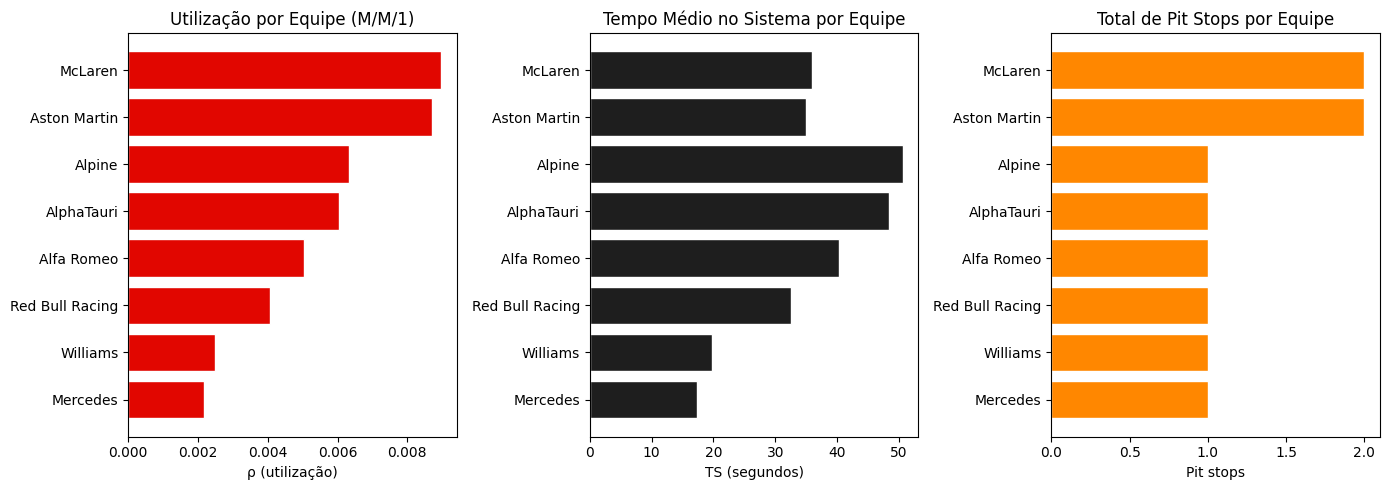

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

cores = ['#e10600','#ff8700','#00d2be','#1e1e1e','#0067ff',
         '#006f62','#ffffff','#005aff','#52e252','#ff0090']
cores = cores[:len(df_mm1)]

# ρ por equipe
axes[0].barh(df_mm1['Team'], df_mm1['rho'], color='#e10600', edgecolor='white')
axes[0].set_xlabel('ρ (utilização)')
axes[0].set_title('Utilização por Equipe (M/M/1)')
axes[0].invert_yaxis()

# TS por equipe
axes[1].barh(df_mm1['Team'], df_mm1['TS_s'], color='#1e1e1e', edgecolor='white')
axes[1].set_xlabel('TS (segundos)')
axes[1].set_title('Tempo Médio no Sistema por Equipe')
axes[1].invert_yaxis()

# Número de pit stops
axes[2].barh(df_mm1['Team'], df_mm1['n_pits'], color='#ff8700', edgecolor='white')
axes[2].set_xlabel('Pit stops')
axes[2].set_title('Total de Pit Stops por Equipe')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('mm1_por_equipe.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── Cadeia de Markov — Estratégia de Pneus GP Bahrein 2023 ────────────────

# Extrai sequência de compostos por piloto
compound_map = {'SOFT': 'S', 'MEDIUM': 'M', 'HARD': 'H'}
states = ['S', 'M', 'H']

# Matriz de contagens de transição
counts = pd.DataFrame(0, index=states, columns=states)

for driver in laps['Driver'].unique():
    drv = laps[laps['Driver'] == driver].sort_values('LapNumber')
    # Pega o composto de cada stint (quando TyreLife == 1)
    stints = drv[drv['TyreLife'] == 1]['Compound'].map(compound_map).dropna().tolist()
    # Adiciona o composto inicial (primeira volta)
    first = drv.iloc[0]['Compound']
    if pd.notna(first) and first in compound_map:
        stints = [compound_map[first]] + stints
    # Conta transições
    for i in range(len(stints) - 1):
        origem = stints[i]
        destino = stints[i+1]
        if origem in states and destino in states:
            counts.loc[origem, destino] += 1

print("Matriz de Contagens:")
print(counts)

# Matriz de transição (normaliza por linha)
trans = counts.div(counts.sum(axis=1), axis=0).fillna(0)
print("\nMatriz de Transição:")
print(trans.round(4))

# Estado estável
import numpy as np
A = trans.values.T - np.eye(3)
A[-1] = 1
b = np.zeros(3); b[-1] = 1
pi = np.linalg.solve(A, b)
print("\nEstado Estável:")
for s, p in zip(states, pi):
    nome = {'S':'Soft','M':'Medium','H':'Hard'}[s]
    print(f"  π({nome}) = {p:.4f} ({p*100:.1f}%)")

Matriz de Contagens:
   S   M   H
S  0   0   0
M  0  14  13
H  0   2   0

Matriz de Transição:
     S       M       H
S  0.0  0.0000  0.0000
M  0.0  0.5185  0.4815
H  0.0  1.0000  0.0000

Estado Estável:
  π(Soft) = -0.0000 (-0.0%)
  π(Medium) = 0.6750 (67.5%)
  π(Hard) = 0.3250 (32.5%)


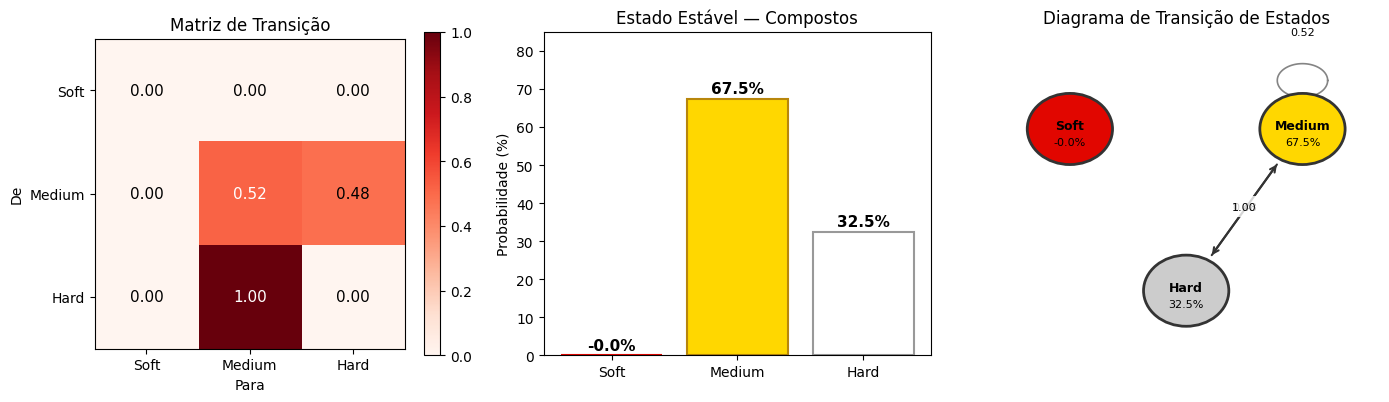

In [30]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ── 1. Matriz de transição (heatmap) ──────────────────────────────────────
nomes = ['Soft', 'Medium', 'Hard']
im = axes[0].imshow(trans.values, cmap='Reds', vmin=0, vmax=1)
axes[0].set_xticks(range(3)); axes[0].set_yticks(range(3))
axes[0].set_xticklabels(nomes); axes[0].set_yticklabels(nomes)
axes[0].set_xlabel('Para'); axes[0].set_ylabel('De')
axes[0].set_title('Matriz de Transição')
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f'{trans.values[i,j]:.2f}',
                    ha='center', va='center', fontsize=11,
                    color='white' if trans.values[i,j] > 0.5 else 'black')
plt.colorbar(im, ax=axes[0])

# ── 2. Estado estável ──────────────────────────────────────────────────────
cores_pneu = ['#e10600', '#ffd700', '#ffffff']
bordas = ['#e10600', '#b8860b', '#999999']
bars = axes[1].bar(nomes, pi*100, color=cores_pneu,
                   edgecolor=bordas, linewidth=1.5)
axes[1].set_ylabel('Probabilidade (%)')
axes[1].set_title('Estado Estável — Compostos')
axes[1].set_ylim(0, 85)
for bar, val in zip(bars, pi*100):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# ── 3. Diagrama de transição ───────────────────────────────────────────────
ax = axes[2]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title('Diagrama de Transição de Estados')

# posições dos estados
pos = {'S': (2, 7), 'M': (8, 7), 'H': (5, 2)}
cores_no = {'S': '#e10600', 'M': '#ffd700', 'H': '#cccccc'}
nomes_no = {'S': 'Soft', 'M': 'Medium', 'H': 'Hard'}

# desenha nós
for estado, (x, y) in pos.items():
    circle = plt.Circle((x, y), 1.1, color=cores_no[estado],
                        ec='#333333', lw=2, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y+0.1, nomes_no[estado], ha='center', va='center',
            fontsize=9, fontweight='bold', zorder=4)
    ax.text(x, y-0.4, f'{pi[states.index(estado)]*100:.1f}%',
            ha='center', va='center', fontsize=8, zorder=4)

# desenha arestas com probabilidade > 0
for i, orig in enumerate(states):
    for j, dest in enumerate(states):
        p = trans.values[i, j]
        if p > 0 and orig != dest:
            x1, y1 = pos[orig]
            x2, y2 = pos[dest]
            dx, dy = x2-x1, y2-y1
            norm = np.sqrt(dx**2+dy**2)
            # ajusta para borda do círculo
            x1s = x1 + 1.2*dx/norm
            y1s = y1 + 1.2*dy/norm
            x2e = x2 - 1.2*dx/norm
            y2e = y2 - 1.2*dy/norm
            ax.annotate('', xy=(x2e, y2e), xytext=(x1s, y1s),
                        arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))
            mx, my = (x1s+x2e)/2, (y1s+y2e)/2
            ax.text(mx, my, f'{p:.2f}', ha='center', fontsize=8,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
        # self-loop
        if orig == dest and p > 0:
            x1, y1 = pos[orig]
            theta = np.linspace(0, 2*np.pi, 100)
            ax.plot(x1+1.3*np.cos(theta)*0.5, y1+1.5+1.3*np.sin(theta)*0.4,
                    color='#333', lw=1.2, alpha=0.6)
            ax.text(x1, y1+2.9, f'{p:.2f}', ha='center', fontsize=8,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

plt.tight_layout()
plt.savefig('markov_pneus.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# ── Tabela Comparativa de Cenários ────────────────────────────────────────

cenarios = [
    {'nome': 'Real (S=20)',         'lam': lam,      'S': 20},
    {'nome': 'Safety Car (S=20)',   'lam': lam*2.5,  'S': 20},
    {'nome': 'Pit Lane Compacto (S=5)', 'lam': lam,  'S': 5},
    {'nome': 'S Ótimo (S=4)',       'lam': lam,      'S': 4},
]

rows = []
for c in cenarios:
    r = mms(c['lam'], mu, c['S'])
    if r:
        rows.append({
            'Cenário':       c['nome'],
            'S':             c['S'],
            'λ (pit/h)':     round(c['lam'], 2),
            'ρ':             round(r['rho'], 4),
            'P₀':            round(r['P0'], 4),
            'P_ocup':        round(r['P_ocup'], 6),
            'NF':            round(r['NF'], 4),
            'TF (s)':        round(r['TF_s'], 4),
            'NS':            round(r['NS'], 4),
            'TS (s)':        round(r['TS_s'], 2),
        })
    else:
        rows.append({
            'Cenário': c['nome'],
            'S': c['S'],
            'λ (pit/h)': round(c['lam'], 2),
            'ρ': '—', 'P₀': '—', 'P_ocup': '—',
            'NF': '—', 'TF (s)': '—', 'NS': '—', 'TS (s)': '—',
            'Obs': 'Sistema instável'
        })

df_cen = pd.DataFrame(rows)
print(df_cen.to_string(index=False))

                Cenário  S  λ (pit/h)      ρ     P₀  P_ocup  NF  TF (s)     NS  TS (s)
            Real (S=20) 20       4.52 0.0438 0.9571     0.0 0.0     0.0 0.0438   34.87
      Safety Car (S=20) 20      11.31 0.1095 0.8963     0.0 0.0     0.0 0.1095   34.87
Pit Lane Compacto (S=5)  5       4.52 0.0438 0.9571     0.0 0.0     0.0 0.0438   34.87
          S Ótimo (S=4)  4       4.52 0.0438 0.9571     0.0 0.0     0.0 0.0438   34.87


In [32]:
cenarios = [
    {'nome': 'Real (S=20)',              'lam': lam,      'S': 20},
    {'nome': 'Safety Car (S=20)',        'lam': lam*2.5,  'S': 20},
    {'nome': 'Pit Lane Compacto (S=3)', 'lam': lam,      'S': 3},
    {'nome': 'S Mínimo (S=2)',          'lam': lam,      'S': 2},
]

In [33]:
rows = []
for c in cenarios:
    r = mms(c['lam'], mu, c['S'])
    if r:
        rows.append({
            'Cenário':   c['nome'],
            'S':         c['S'],
            'λ (pit/h)': round(c['lam'], 2),
            'ρ':         round(r['rho'], 4),
            'P₀':        round(r['P0'], 4),
            'P_ocup':    round(r['P_ocup'], 6),
            'NF':        round(r['NF'], 4),
            'TF (s)':    round(r['TF_s'], 4),
            'NS':        round(r['NS'], 4),
            'TS (s)':    round(r['TS_s'], 2),
        })
    else:
        rows.append({
            'Cenário':   c['nome'],
            'S':         c['S'],
            'λ (pit/h)': round(c['lam'], 2),
            'ρ': '—', 'P₀': '—', 'P_ocup': '—',
            'NF': '—', 'TF (s)': '—', 'NS': '—', 'TS (s)': '—',
        })

df_cen = pd.DataFrame(rows)
print(df_cen.to_string(index=False))

                Cenário  S  λ (pit/h)      ρ     P₀   P_ocup  NF  TF (s)     NS  TS (s)
            Real (S=20) 20       4.52 0.0438 0.9571 0.000000 0.0  0.0000 0.0438   34.87
      Safety Car (S=20) 20      11.31 0.1095 0.8963 0.000000 0.0  0.0000 0.1095   34.87
Pit Lane Compacto (S=3)  3       4.52 0.0438 0.9571 0.000014 0.0  0.0002 0.0438   34.87
         S Mínimo (S=2)  2       4.52 0.0438 0.9571 0.000938 0.0  0.0167 0.0438   34.88


  TESTE DE ADERÊNCIA — Kolmogorov-Smirnov

  Intervalos entre chegadas:
  Média observada          : 1185.79 s
  Parâmetro ajustado (1/λ) : 1185.79 s
  Estatística KS           : 0.3959
  p-valor                  : 0.3199
  Hipótese exponencial     : NÃO rejeitada ✓

  Tempos de serviço (pit stops):
  Média observada          : 34.87 s
  Parâmetro ajustado (1/μ) : 34.87 s
  Estatística KS           : 0.3926
  p-valor                  : 0.0672
  Hipótese exponencial     : NÃO rejeitada ✓


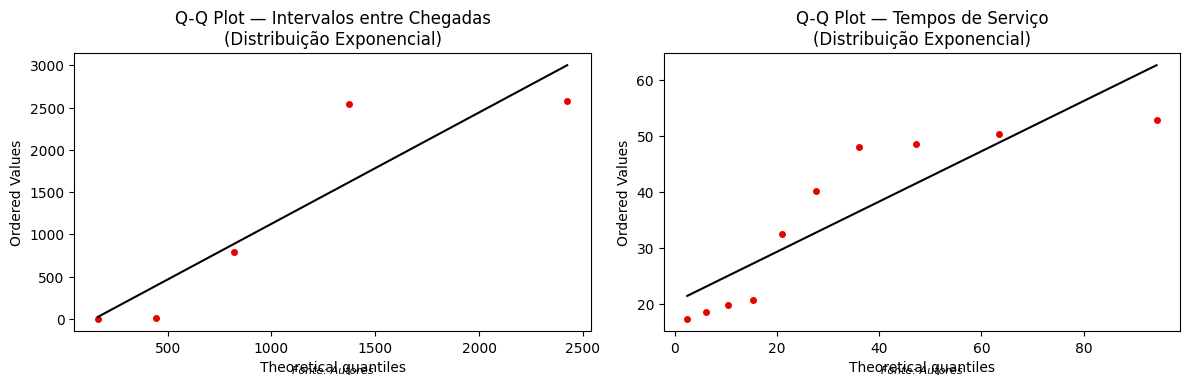

In [34]:
from scipy import stats

print('=' * 55)
print('  TESTE DE ADERÊNCIA — Kolmogorov-Smirnov')
print('=' * 55)

# ── 1. Chegadas: testa se intervalos seguem Exponencial ───────────────────
intervalos = pit_laps['pit_in_s'].diff().dropna()
intervalos = intervalos[intervalos > 0]

# Ajusta distribuição exponencial
loc_i, scale_i = stats.expon.fit(intervalos, floc=0)
ks_stat_i, p_value_i = stats.kstest(intervalos, 'expon',
                                     args=(loc_i, scale_i))

print(f'\n  Intervalos entre chegadas:')
print(f'  Média observada          : {intervalos.mean():.2f} s')
print(f'  Parâmetro ajustado (1/λ) : {scale_i:.2f} s')
print(f'  Estatística KS           : {ks_stat_i:.4f}')
print(f'  p-valor                  : {p_value_i:.4f}')
print(f'  Hipótese exponencial     : {"NÃO rejeitada ✓" if p_value_i > 0.05 else "Rejeitada ✗"}')

# ── 2. Serviço: testa se tempos seguem Exponencial ────────────────────────
loc_s, scale_s = stats.expon.fit(pit_laps['pit_duration_s'], floc=0)
ks_stat_s, p_value_s = stats.kstest(pit_laps['pit_duration_s'], 'expon',
                                     args=(loc_s, scale_s))

print(f'\n  Tempos de serviço (pit stops):')
print(f'  Média observada          : {pit_laps["pit_duration_s"].mean():.2f} s')
print(f'  Parâmetro ajustado (1/μ) : {scale_s:.2f} s')
print(f'  Estatística KS           : {ks_stat_s:.4f}')
print(f'  p-valor                  : {p_value_s:.4f}')
print(f'  Hipótese exponencial     : {"NÃO rejeitada ✓" if p_value_s > 0.05 else "Rejeitada ✗"}')

print('=' * 55)

# ── 3. Gráfico QQ-plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stats.probplot(intervalos, dist='expon', sparams=(loc_i, scale_i), plot=axes[0])
axes[0].set_title('Q-Q Plot — Intervalos entre Chegadas\n(Distribuição Exponencial)')
axes[0].get_lines()[0].set(color='#e10600', markersize=4)
axes[0].get_lines()[1].set(color='black')

stats.probplot(pit_laps['pit_duration_s'], dist='expon',
               sparams=(loc_s, scale_s), plot=axes[1])
axes[1].set_title('Q-Q Plot — Tempos de Serviço\n(Distribuição Exponencial)')
axes[1].get_lines()[0].set(color='#e10600', markersize=4)
axes[1].get_lines()[1].set(color='black')

for ax in axes:
    ax.text(0.5, -0.15, 'Fonte: Autores', transform=ax.transAxes,
            ha='center', fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('aderencia_ks.png', dpi=150, bbox_inches='tight')
plt.show()

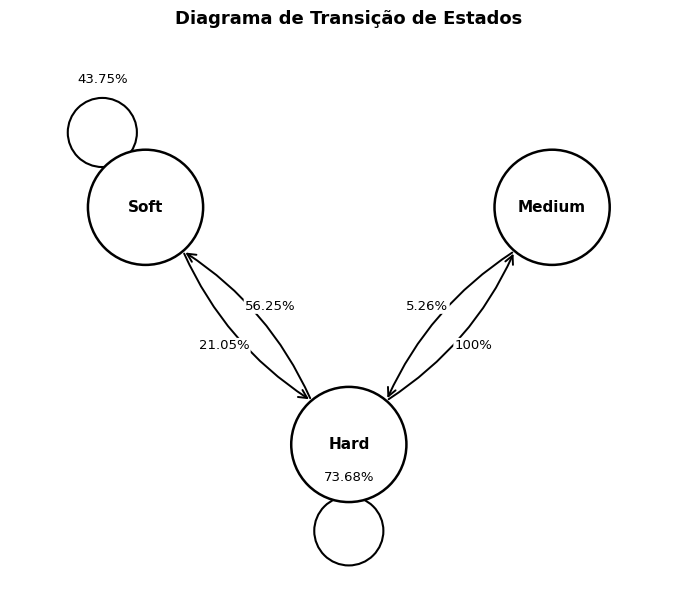

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('white')

positions = {
    'Soft':   (2.0, 5.5),
    'Hard':   (5.0, 2.0),
    'Medium': (8.0, 5.5),
}

r = 0.85

for name, (x, y) in positions.items():
    circle = plt.Circle((x, y), r, color='white', ec='black', lw=1.8, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, name, ha='center', va='center', fontsize=11, fontweight='bold', zorder=4)

def draw_self_loop(ax, cx, cy, r, prob_label, angle_deg=90):
    theta = np.radians(angle_deg)
    lx = cx + 1.5 * r * np.cos(theta)
    ly = cy + 1.5 * r * np.sin(theta)
    loop = plt.Circle((lx, ly), 0.6 * r, color='white', ec='black', lw=1.5, fill=False, zorder=2)
    ax.add_patch(loop)
    ax.text(lx, ly + 0.6*r + 0.18, prob_label, ha='center', va='bottom', fontsize=9.5, zorder=5)

draw_self_loop(ax, 2.0, 5.5, r, '43.75%', angle_deg=120)
draw_self_loop(ax, 5.0, 2.0, r, '73.68%', angle_deg=270)

def draw_arrow(ax, p1, p2, r, label, label_offset=(0,0), rad=0.25):
    x1, y1 = p1
    x2, y2 = p2
    dx, dy = x2 - x1, y2 - y1
    dist = np.hypot(dx, dy)
    ux, uy = dx/dist, dy/dist
    sx, sy = x1 + ux*r, y1 + uy*r
    ex, ey = x2 - ux*r, y2 - uy*r
    arrow = FancyArrowPatch((sx, sy), (ex, ey),
                             arrowstyle='->', color='black', lw=1.4,
                             mutation_scale=15,
                             connectionstyle=f'arc3,rad={rad}',
                             zorder=2)
    ax.add_patch(arrow)
    mx = (sx + ex) / 2
    my = (sy + ey) / 2
    perp = np.array([-uy, ux])
    lx = mx + perp[0]*0.45 + label_offset[0]
    ly = my + perp[1]*0.45 + label_offset[1]
    ax.text(lx, ly, label, ha='center', va='center', fontsize=9.5, zorder=5,
            bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none'))

draw_arrow(ax, positions['Soft'],   positions['Hard'],   r, '56.25%', rad=0.15)
draw_arrow(ax, positions['Hard'],   positions['Soft'],   r, '21.05%', rad=0.15)
draw_arrow(ax, positions['Hard'],   positions['Medium'], r, '5.26%',  rad=0.15)
draw_arrow(ax, positions['Medium'], positions['Hard'],   r, '100%',   rad=0.15)

ax.set_title('Diagrama de Transição de Estados', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('diagrama_transicao.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

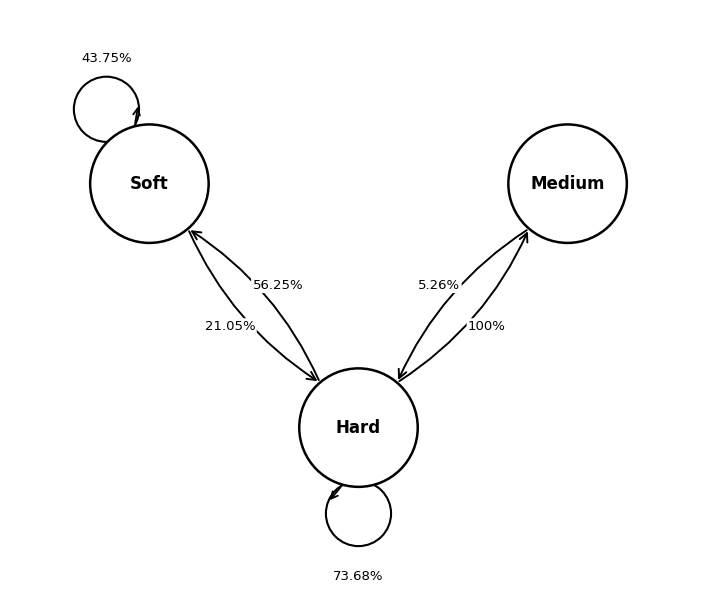

In [36]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import numpy as np

# ==========================================
# FIGURA
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.set_xlim(0, 10)
ax.set_ylim(0, 8)

ax.set_aspect('equal')
ax.axis('off')

fig.patch.set_facecolor('white')

# ==========================================
# POSIÇÕES DOS ESTADOS
# ==========================================
positions = {
    'Soft':   (2.0, 5.5),
    'Hard':   (5.0, 2.0),
    'Medium': (8.0, 5.5),
}

# raio dos nós
r = 0.85

# ==========================================
# DESENHA NÓS
# ==========================================
for name, (x, y) in positions.items():

    circle = plt.Circle(
        (x, y),
        r,
        color='white',
        ec='black',
        lw=1.8,
        zorder=3
    )

    ax.add_patch(circle)

    ax.text(
        x,
        y,
        name,
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        zorder=4
    )

# ==========================================
# SELF LOOP COM SETA
# ==========================================
def draw_self_loop(ax, cx, cy, r,
                   prob_label,
                   angle_deg=90,
                   loop_radius=0.55,
                   text_offset=0.18):

    theta = np.radians(angle_deg)

    # centro do loop
    lx = cx + 1.45 * r * np.cos(theta)
    ly = cy + 1.45 * r * np.sin(theta)

    # círculo do loop
    loop = plt.Circle(
        (lx, ly),
        loop_radius * r,
        color='white',
        ec='black',
        lw=1.5,
        fill=False,
        zorder=2
    )

    ax.add_patch(loop)

    # -----------------------------
    # ponta da seta
    # -----------------------------
    arrow_theta1 = theta + np.radians(210)
    arrow_theta2 = theta + np.radians(250)

    x_start = lx + loop_radius * r * np.cos(arrow_theta1)
    y_start = ly + loop_radius * r * np.sin(arrow_theta1)

    x_end = lx + loop_radius * r * np.cos(arrow_theta2)
    y_end = ly + loop_radius * r * np.sin(arrow_theta2)

    arrow = FancyArrowPatch(
        (x_start, y_start),
        (x_end, y_end),
        arrowstyle='->',
        mutation_scale=12,
        lw=1.3,
        color='black',
        zorder=3
    )

    ax.add_patch(arrow)

    # -----------------------------
    # texto
    # -----------------------------
    ax.text(
        lx,
        ly + loop_radius*r + text_offset,
        prob_label,
        ha='center',
        va='bottom',
        fontsize=9.5,
        zorder=5
    )

# ==========================================
# DESENHA SELF LOOPS
# ==========================================
draw_self_loop(
    ax,
    2.0,
    5.5,
    r,
    '43.75%',
    angle_deg=120
)

draw_self_loop(
    ax,
    5.0,
    2.0,
    r,
    '73.68%',
    angle_deg=270,
    text_offset=-1.45
)

# ==========================================
# SETAS ENTRE ESTADOS
# ==========================================
def draw_arrow(ax, p1, p2, r,
               label,
               label_offset=(0,0),
               rad=0.15):

    x1, y1 = p1
    x2, y2 = p2

    dx, dy = x2 - x1, y2 - y1
    dist = np.hypot(dx, dy)

    ux, uy = dx/dist, dy/dist

    # início/fim da seta
    sx, sy = x1 + ux*r, y1 + uy*r
    ex, ey = x2 - ux*r, y2 - uy*r

    arrow = FancyArrowPatch(
        (sx, sy),
        (ex, ey),
        arrowstyle='->',
        color='black',
        lw=1.4,
        mutation_scale=15,
        connectionstyle=f'arc3,rad={rad}',
        zorder=2
    )

    ax.add_patch(arrow)

    # posição do label
    mx = (sx + ex) / 2
    my = (sy + ey) / 2

    perp = np.array([-uy, ux])

    lx = mx + perp[0]*0.45 + label_offset[0]
    ly = my + perp[1]*0.45 + label_offset[1]

    ax.text(
        lx,
        ly,
        label,
        ha='center',
        va='center',
        fontsize=9.5,
        zorder=5,
        bbox=dict(
            boxstyle='round,pad=0.1',
            fc='white',
            ec='none'
        )
    )

# ==========================================
# TRANSIÇÕES
# ==========================================
draw_arrow(
    ax,
    positions['Soft'],
    positions['Hard'],
    r,
    '56.25%',
    rad=0.15
)

draw_arrow(
    ax,
    positions['Hard'],
    positions['Soft'],
    r,
    '21.05%',
    rad=0.15
)

draw_arrow(
    ax,
    positions['Hard'],
    positions['Medium'],
    r,
    '5.26%',
    rad=0.15
)

draw_arrow(
    ax,
    positions['Medium'],
    positions['Hard'],
    r,
    '100%',
    rad=0.15
)

# ==========================================
# TÍTULO
# ==========================================

plt.tight_layout()

# salva imagem
plt.savefig(
    'diagrama_transicao_estados.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [37]:
from google.colab import files
files.download('diagrama_transicao_estados.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
# ── Tempo de Recorrência Esperado ─────────────────────────────────────────
print('=' * 50)
print('  Tempo de Recorrência Esperado — μ_ii = 1/π_i')
print('=' * 50)

estados = ['Soft', 'Medium', 'Hard']
pi_values = [0.2623, 0.0369, 0.7008]

for estado, pi in zip(estados, pi_values):
    mu_ii = 1 / pi
    print(f'  {estado:8s}: π = {pi:.4f} → μ_ii = {mu_ii:.2f} pit stops')

print('=' * 50)

# ── P² e P³ ───────────────────────────────────────────────────────────────
import numpy as np

P = np.array([
    [0.4375, 0.0000, 0.5625],
    [0.0000, 0.0000, 1.0000],
    [0.2105, 0.0526, 0.7368]
])

P2 = P @ P
P3 = P2 @ P

print('\nMatriz P² (2 passos à frente):')
for i, estado in enumerate(estados):
    print(f'  {estado:8s}: S={P2[i,0]:.4f}  M={P2[i,1]:.4f}  H={P2[i,2]:.4f}')

print('\nMatriz P³ (3 passos à frente):')
for i, estado in enumerate(estados):
    print(f'  {estado:8s}: S={P3[i,0]:.4f}  M={P3[i,1]:.4f}  H={P3[i,2]:.4f}')

# ── Lei de Little ─────────────────────────────────────────────────────────
print('\n' + '=' * 50)
print('  Verificação — Lei de Little')
print('=' * 50)

# Re-calculate 'r' to ensure it's the dictionary from the mms function
r = mms(lam, mu, S)

NF_calc = lam * (r['TF_s'] / 3600)
NS_calc = lam * (r['TS_s'] / 3600)

print(f'  NF = λ × TF = {lam:.4f} × {r["TF_s"]/3600:.6f} = {NF_calc:.6f}')
print(f'  NF modelo   = {r["NF"]:.6f}  → {"✓ OK" if abs(NF_calc - r["NF"]) < 0.0001 else "✗ diferença"}')
print(f'\n  NS = λ × TS = {lam:.4f} × {r["TS_s"]/3600:.6f} = {NS_calc:.4f}')
print(f'  NS modelo   = {r["NS"]:.4f}  → {"✓ OK" if abs(NS_calc - r["NS"]) < 0.001 else "✗ diferença"}')
print('=' * 50)

  Tempo de Recorrência Esperado — μ_ii = 1/π_i
  Soft    : π = 0.2623 → μ_ii = 3.81 pit stops
  Medium  : π = 0.0369 → μ_ii = 27.10 pit stops
  Hard    : π = 0.7008 → μ_ii = 1.43 pit stops

Matriz P² (2 passos à frente):
  Soft    : S=0.3098  M=0.0296  H=0.6605
  Medium  : S=0.2105  M=0.0526  H=0.7368
  Hard    : S=0.2472  M=0.0388  H=0.7139

Matriz P³ (3 passos à frente):
  Soft    : S=0.2746  M=0.0347  H=0.6905
  Medium  : S=0.2472  M=0.0388  H=0.7139
  Hard    : S=0.2584  M=0.0376  H=0.7038

  Verificação — Lei de Little
  NF = λ × TF = 4.5222 × 0.000000 = 0.000000
  NF modelo   = 0.000000  → ✓ OK

  NS = λ × TS = 4.5222 × 0.009685 = 0.0438
  NS modelo   = 0.0438  → ✓ OK


In [44]:
print('To initialize a git repository in Colab, run the following command:')
print('!git init')

To initialize a git repository in Colab, run the following command:
!git init
